# 02. Análisis Exploratorio de Datos (EDA)

In [31]:
# Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings("ignore")

In [32]:
#Captura de datos y visualización de los primeros registros.
url_heart = "https://raw.githubusercontent.com/sharmaroshan/Heart-UCI-Dataset/master/heart.csv"
df_heart = pd.read_csv(url_heart)
print(df_heart.head())
print(df_heart.shape)

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  
(303, 14)


In [33]:
# Guardar el DataFrame en un archivo CSV con validación de la ruta
RUTA_CSV = os.path.join("..", "data", "Heart_Disease_UCI.csv")
if not os.path.exists(os.path.dirname(RUTA_CSV)):
    os.makedirs(os.path.dirname(RUTA_CSV))
    
df_heart.to_csv(RUTA_CSV, index=False)

## 2.1 Revisión de valores faltantes:


In [34]:
# Verificación de los primeros registros del DataFrame.
df_heart.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [35]:
# Verificación de tamañao del DataFrame.
df_heart.shape

(303, 14)

In [36]:
# verificación de registros, tipos de datos y valores nulos en el DataFrame.
df_heart.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [37]:
# Revisión de valores faltantes
valores_faltantes = df_heart.isnull().sum()
porcentaje_faltantes = (valores_faltantes / len(df_heart)) * 100

resumen_faltantes = pd.DataFrame({
    "valores_faltantes": valores_faltantes,
    "porcentaje (%)": porcentaje_faltantes.round(2)
})
resumen_faltantes = resumen_faltantes[resumen_faltantes["valores_faltantes"] > 0]

if resumen_faltantes.empty:
    print("No se encontraron valores faltantes en ninguna columna.")
else:
    print("Columnas con valores faltantes:")
    print(resumen_faltantes.sort_values("porcentaje (%)", ascending=False))

No se encontraron valores faltantes en ninguna columna.


## 2.2 Detección de valores atípicos:

In [38]:
# Detección de valores atípicos.
# Estadisticas descriptivas de variables numericas.
numeric_cols = df_heart.select_dtypes(include="number").columns.tolist()
print(f"Variables numericas disponibles: {numeric_cols}")
print(len(numeric_cols))
df_heart[numeric_cols].describe().round(2)

Variables numericas disponibles: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
14


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00
mean,54.37,0.68,0.97,131.62,246.26,0.15,0.53,149.65,0.33,1.04,1.40,0.73,2.31,0.54
std,9.08,0.47,1.03,17.54,51.83,0.36,0.53,22.91,0.47,1.16,0.62,1.02,0.61,0.50
min,29.00,0.00,0.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,47.50,0.00,0.00,120.00,211.00,0.00,0.00,133.50,0.00,0.00,1.00,0.00,2.00,0.00
50%,55.00,1.00,1.00,130.00,240.00,0.00,1.00,153.00,0.00,0.80,1.00,0.00,2.00,1.00
75%,61.00,1.00,2.00,140.00,274.50,0.00,1.00,166.00,1.00,1.60,2.00,1.00,3.00,1.00
max,77.00,1.00,3.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,2.00,4.00,3.00,1.00


In [39]:
# Implementación de la detección de outliers utilizando el método IQR (Interquartile Range).
resumen_outliers_iqr = []
for col in numeric_cols:
    q1 = df_heart[col].quantile(0.25)
    q3 = df_heart[col].quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    outliers = df_heart[(df_heart[col] < limite_inferior) | (df_heart[col] > limite_superior)]
    resumen_outliers_iqr.append({
        "columna": col,
        "outliers_iqr": len(outliers),
        "porcentaje (%)": round(100 * len(outliers) / len(df_heart), 2)
    })
    
resumen_outliers_iqr = pd.DataFrame(resumen_outliers_iqr).sort_values(
    "outliers_iqr", ascending=False
)
print("Outliers detectados por IQR:")
print(resumen_outliers_iqr[resumen_outliers_iqr["outliers_iqr"] > 0])

Outliers detectados por IQR:
     columna  outliers_iqr  porcentaje (%)
5        fbs            45           14.85
11        ca            25            8.25
3   trestbps             9            2.97
4       chol             5            1.65
9    oldpeak             5            1.65
12      thal             2            0.66
7    thalach             1            0.33


In [40]:
# Variables cuantitativas continuas para evaluar posibles outliers
columnas_continuas = ["age", "trestbps", "chol", "thalach", "oldpeak"]

# Límites IQR y puntuaciones Z
resumen_outliers = []

for col in columnas_continuas:
    serie = df_heart[col]
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    z_score = (serie - serie.mean()) / serie.std()

    es_outlier_iqr = (serie < limite_inferior) | (serie > limite_superior)
    es_outlier_z = z_score.abs() > 3

    resumen_outliers.append({
        "columna": col,
        "outliers_IQR": int(es_outlier_iqr.sum()),
        "outliers_Z_score": int(es_outlier_z.sum())
    })

print("Resumen de posibles outliers:")
display(pd.DataFrame(resumen_outliers))

Resumen de posibles outliers:


,columna,outliers_IQR,outliers_Z_score
0,age,0,0
1,trestbps,9,2
2,chol,5,4
3,thalach,1,1
4,oldpeak,5,2


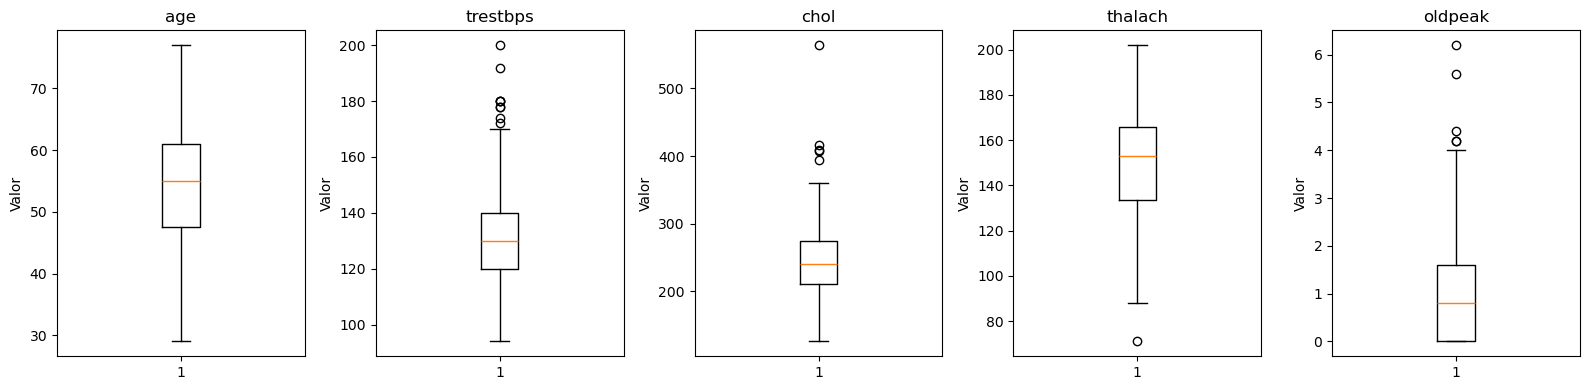

In [41]:
# Boxplots de las variables continuas.
fig, axes = plt.subplots(1, len(columnas_continuas), figsize=(16, 4))
for ax, col in zip(axes, columnas_continuas):
    ax.boxplot(df_heart[col].dropna())
    ax.set_title(col)
    ax.set_ylabel("Valor")
plt.tight_layout()
plt.show()

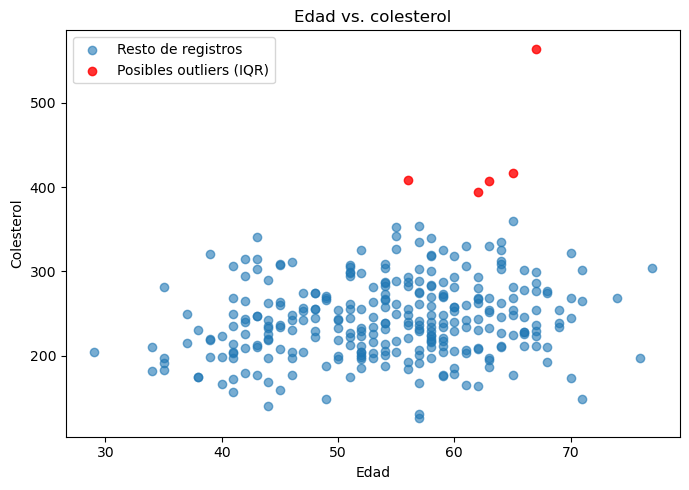

In [42]:
# Diagrama de dispersión: Edad vs. Colesterol.
# Se resaltan registros que son atípicos por IQR en cualquiera de las dos variables.
x_col, y_col = "age", "chol"

def mascara_outliers_iqr(serie):
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    return (serie < q1 - 1.5 * iqr) | (serie > q3 + 1.5 * iqr)

posibles_outliers = (
    mascara_outliers_iqr(df_heart[x_col]) |
    mascara_outliers_iqr(df_heart[y_col])
)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(
    df_heart.loc[~posibles_outliers, x_col],
    df_heart.loc[~posibles_outliers, y_col],
    alpha=0.6,
    label="Resto de registros"
)
ax.scatter(
    df_heart.loc[posibles_outliers, x_col],
    df_heart.loc[posibles_outliers, y_col],
    color="red",
    alpha=0.8,
    label="Posibles outliers (IQR)"
)
ax.set_xlabel("Edad")
ax.set_ylabel("Colesterol")
ax.set_title("Edad vs. colesterol")
ax.legend()
plt.tight_layout()
plt.show()

## 2.3 Análisis de distribuaciones y 2.4 Análisis univariago

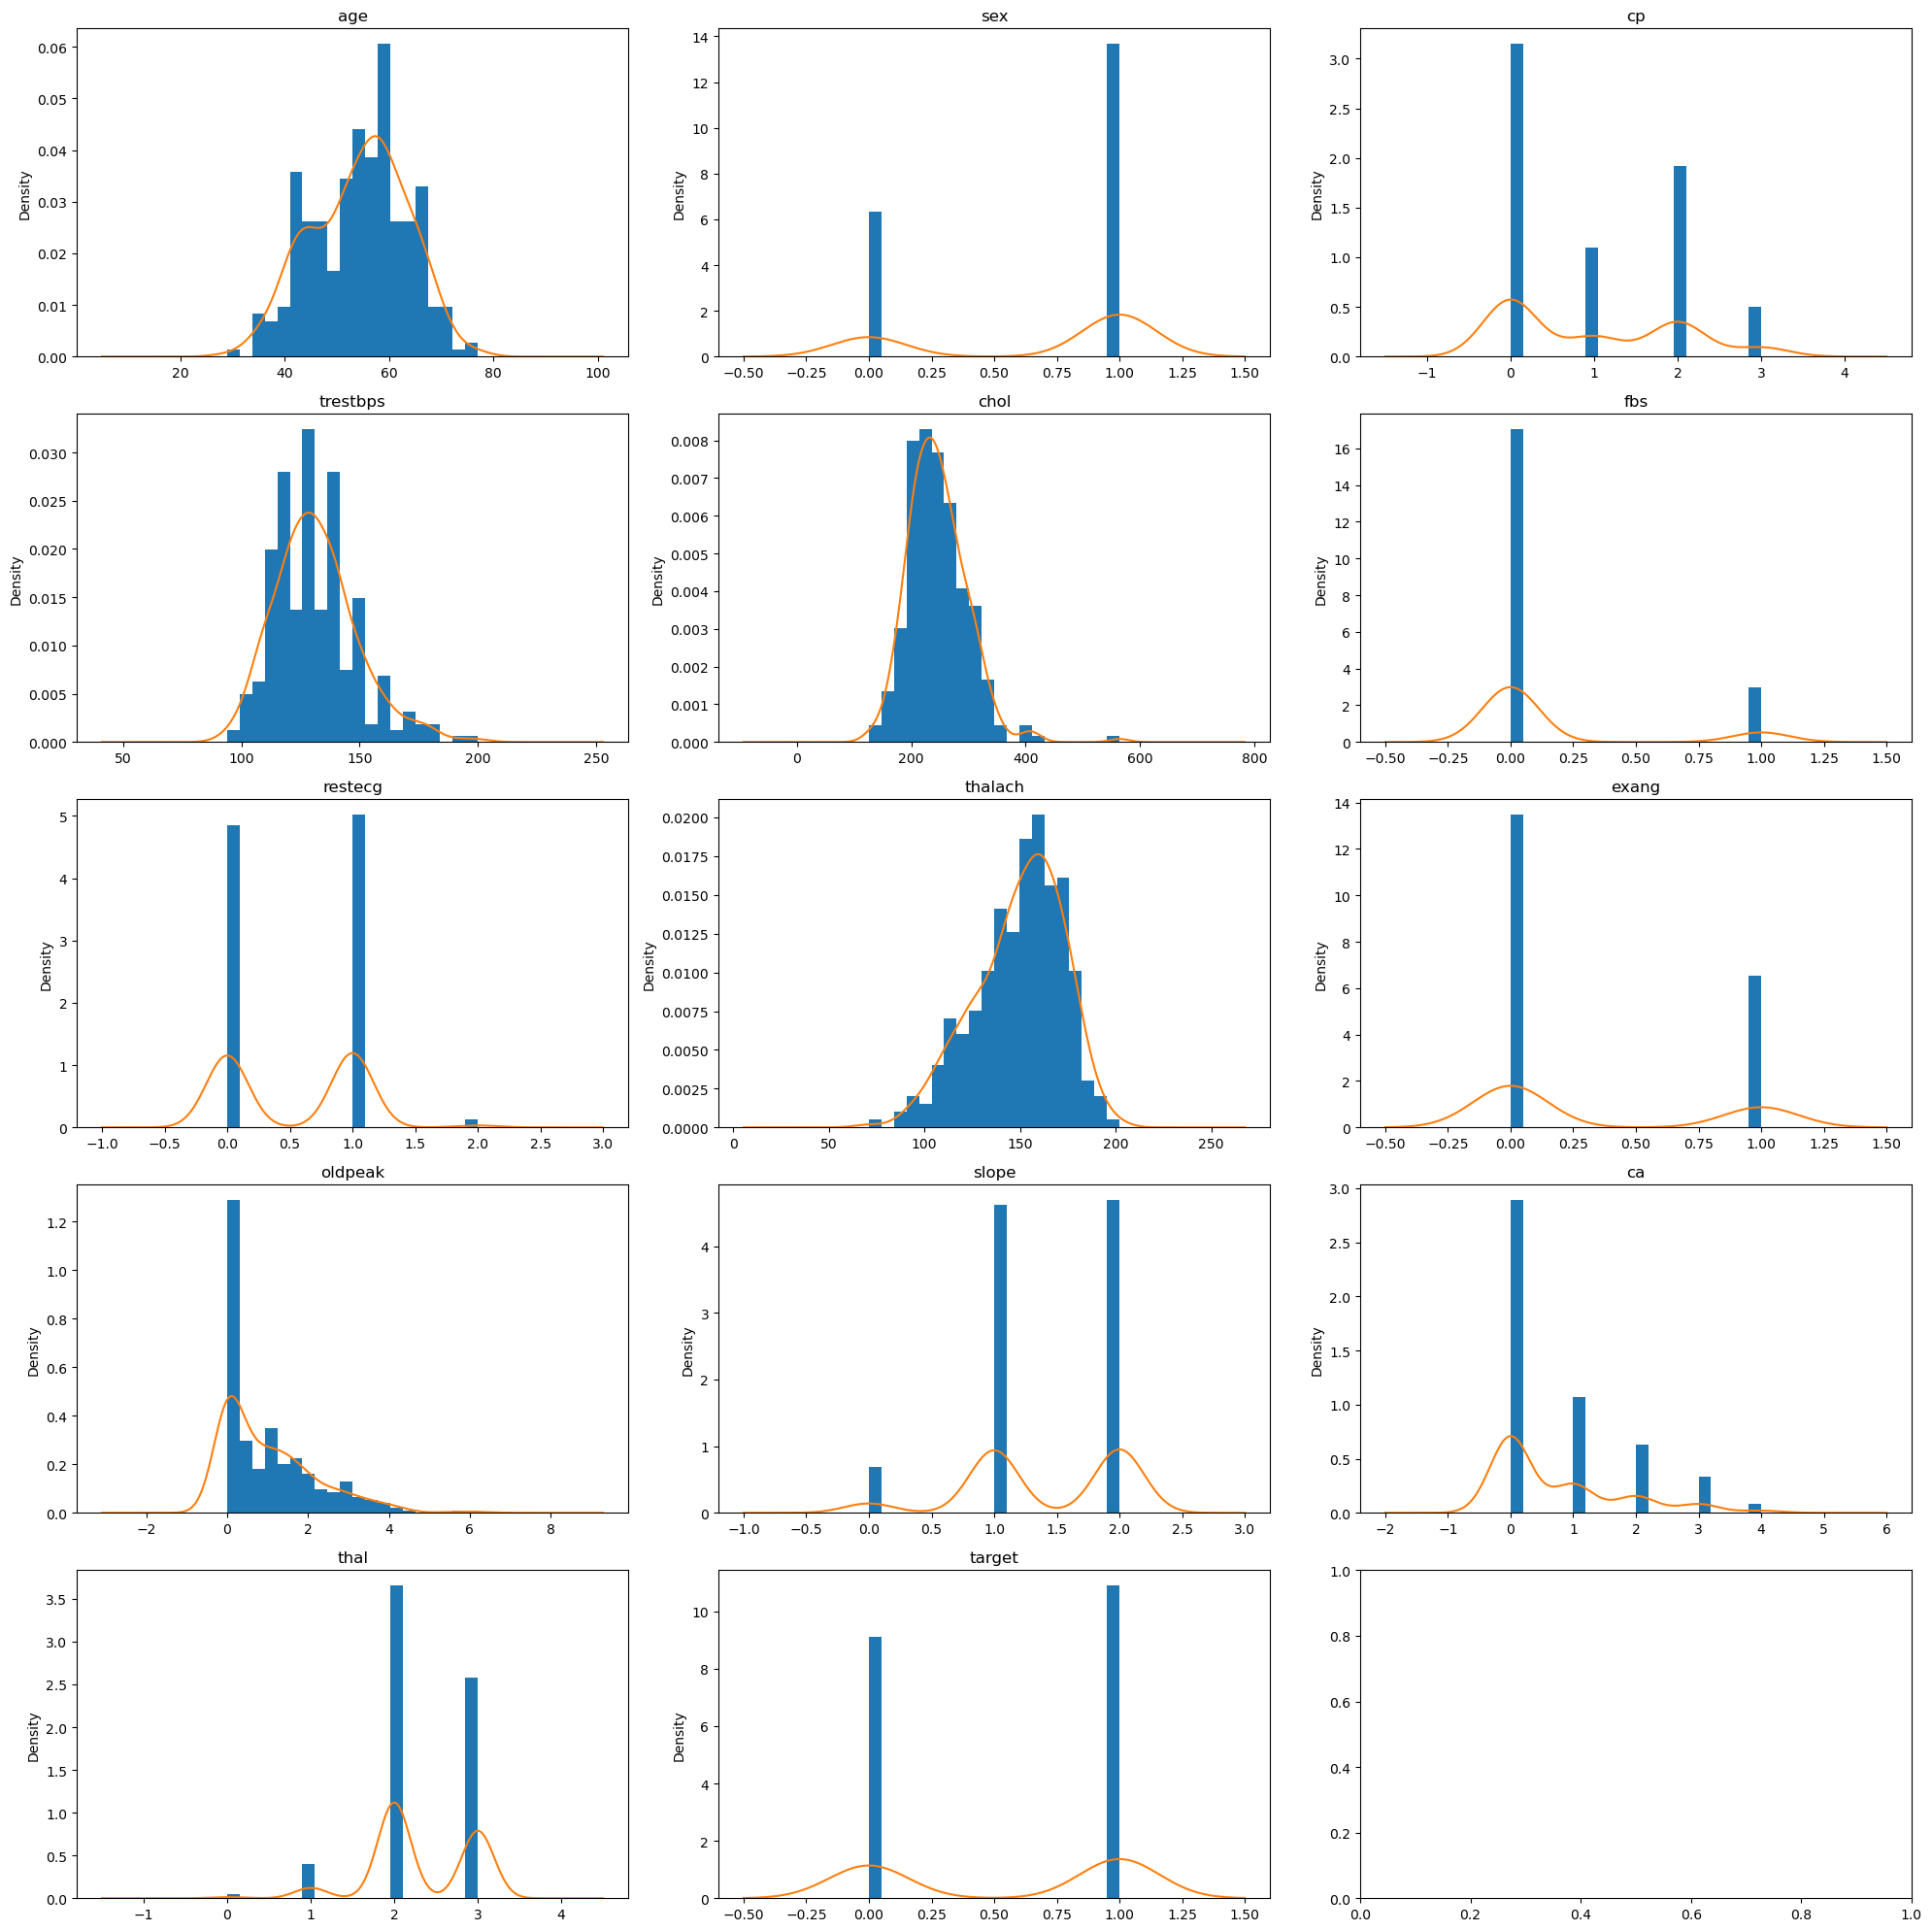

age        -0.202463
sex        -0.791335
cp          0.484732
trestbps    0.713768
chol        1.143401
fbs         1.986652
restecg     0.162522
thalach    -0.537410
exang       0.742532
oldpeak     1.269720
slope      -0.508316
ca          1.310422
thal       -0.476722
target     -0.179821
dtype: float64


In [49]:
# Análisis de distribuciones: histograma + densidad
columnas_numericas = df_heart.select_dtypes(include=np.number).columns
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(20, 20))
axes = axes.flatten()

for ax, col in zip(axes, columnas_numericas):
    df_heart[col].plot(kind="hist", bins=20, density=True, ax=ax, title=col)
    if df_heart[col].std() > 0:
        df_heart[col].plot(kind="kde", ax=ax)

plt.tight_layout()
plt.show()

# Sesgo de cada variable (se identifica posibles transformaciones necesarias)
print(df_heart[columnas_numericas].skew())